In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import joblib

# Create model directory if it doesn't exist
MODEL_DIR = 'models'
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

In [37]:
def load_dataset(file_path):
    """Load the dataset from CSV file."""
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

In [38]:
def preprocess_data(df, is_train=True):
    """Preprocess the dataset: handle missing values, encode target, and scale features."""
    # Create a copy to avoid modifying the original dataframe
    df = df.copy()
    
    # Handle missing values
    df = df.dropna()
    
    # If training data, encode target variable
    if is_train:
        df['decision_outcome'] = df['decision_outcome'].map({'Effective': 1, 'Not Effective': 0})
    
    # Separate features and target
    if is_train:
        X = df.drop('decision_outcome', axis=1)
        y = df['decision_outcome']
    else:
        X = df
        y = None
    
    # Scale numerical features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    # Save scaler for test data
    if is_train:
        joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))
    
    return X_scaled, y, scaler if is_train else X_scaled

In [39]:
def perform_eda(df, save_path='eda_plots'):
    """Perform Exploratory Data Analysis and generate 5 plots."""
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # 1. Correlation Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Features')
    plt.savefig(os.path.join(save_path, 'correlation_heatmap.png'))
    plt.show()
    
    # 2. Distribution of Decision Outcome
    plt.figure(figsize=(8, 6))
    sns.countplot(x='decision_outcome', data=df)
    plt.title('Distribution of Decision Outcome')
    plt.savefig(os.path.join(save_path, 'decision_outcome_distribution.png'))
    plt.show()
    
    # 3. Box Plot of Transaction Volume by Decision Outcome
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='decision_outcome', y='transaction_volume', data=df)
    plt.title('Transaction Volume by Decision Outcome')
    plt.savefig(os.path.join(save_path, 'transaction_volume_boxplot.png'))
    plt.show()
    
    # 4. Scatter Plot of Financial Metric vs System Throughput
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='financial_metric', y='system_throughput', hue='decision_outcome', data=df)
    plt.title('Financial Metric vs System Throughput')
    plt.savefig(os.path.join(save_path, 'financial_metric_vs_throughput.png'))
    plt.show()
    
    # 5. Histogram of Resource Utilization
    plt.figure(figsize=(8, 6))
    sns.histplot(df['resource_utilization'], bins=30, kde=True)
    plt.title('Distribution of Resource Utilization')
    plt.savefig(os.path.join(save_path, 'resource_utilization_histogram.png'))
    plt.show()


In [40]:
def train_test_split_data(X, y, test_size=0.2, random_state=42):
    """Split the dataset into training and testing sets."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

In [41]:
def evaluate_performance(y_true, y_pred, model_name, plot_cm=True, save_path='plots'):
    """Evaluate model performance and plot confusion matrix."""
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    # Print metrics
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"Accuracy (A):  {accuracy:.4f}")
    print(f"Precision (P): {precision:.4f}")
    print(f"Recall (R):    {recall:.4f}")
    print(f"F1 Score:      {f1:.4f}")
    # Print classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=['Not Effective', 'Effective']))
    
    # Plot confusion matrix
    if plot_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Effective', 'Effective'], yticklabels=['Not Effective', 'Effective'])
        plt.title(f'Confusion Matrix for {model_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(os.path.join(save_path, f'{model_name}_confusion_matrix.png'))
        plt.show()
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

In [42]:
def train_extra_trees(X_train, y_train, model_path=os.path.join(MODEL_DIR, 'extra_trees.pkl')):
    """Train and save Extra Trees Classifier."""
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print("Loaded existing Extra Trees model")
    else:
        model = ExtraTreesClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print("Trained and saved Extra Trees model")
    return model

In [43]:
def train_catboost(X_train, y_train, model_path=os.path.join(MODEL_DIR, 'catboost.pkl')):
    """Train and save CatBoost Classifier."""
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print("Loaded existing CatBoost model")
    else:
        model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, random_seed=42, verbose=0)
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print("Trained and saved CatBoost model")
    return model

In [44]:
def train_lightgbm(X_train, y_train, model_path=os.path.join(MODEL_DIR, 'lightgbm.pkl')):
    """Train and save LightGBM Classifier."""
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print("Loaded existing LightGBM model")
    else:
        model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
        model.fit(X_train, y_train)
        joblib.dump(model, model_path)
        print("Trained and saved LightGBM model")
    return model

In [62]:
def predict_test_data(test_file_path, model_name='extra_trees'):
    """Preprocess test data and make predictions using the specified model."""
    # Load test data
    test_df = load_dataset(test_file_path)
    if test_df is None:
        return None
    
    # Preprocess test data (unpack features)
    X_test_scaled = preprocess_data(test_df, is_train=False)[0]
    
    # Load model
    model_path = os.path.join(MODEL_DIR, f'{model_name.lower()}.pkl')
    if not os.path.exists(model_path):
        print(f"Model {model_name} not found!")
        return None
    
    model = joblib.load(model_path)
    
    # Make predictions
    predictions = model.predict(X_test_scaled)
    
    # Map predictions back to original categories
    predictions_mapped = np.where(predictions == 1, 'Effective', 'Not Effective')
    
    # Create output dataframe
    output_df = test_df.copy()
    output_df['predicted_decision_outcome'] = predictions_mapped
    
    return output_df


In [63]:
train_file_path = 'economic_management_dataset.csv'
df = load_dataset(train_file_path)
df

,transaction_volume,market_behavior_index,financial_metric,edge_processing_latency,resource_utilization,workload_distribution_efficiency,decision_accuracy,system_throughput,decision_outcome
0,1717,-0.702675,74.296381,472.107160,0.947553,78.856129,84.217637,9901,Not Effective
1,3782,-0.170752,42.606784,127.939429,0.701715,67.856058,91.491913,3618,Effective
2,5946,-0.829301,34.658906,69.535674,0.710803,89.377454,78.128281,7289,Not Effective
3,6486,0.993749,37.166772,106.760540,0.425728,62.550069,76.067625,7928,Not Effective
4,9335,0.004390,98.766191,444.593201,0.634295,78.203701,79.414804,6368,Not Effective
...,...,...,...,...,...,...,...,...,...
495,3713,-0.938695,22.539100,215.284417,0.434552,82.706637,90.515994,8354,Effective
496,6588,-0.484634,37.279486,378.077243,0.453212,94.456396,85.947165,5516,Effective
497,1966,-0.074754,43.264481,44.793756,0.778838,78.940338,70.979772,4622,Not Effective
498,5944,0.736545,43.996558,49.288207,0.926584,81.619566,84.267886,5399,Not Effective


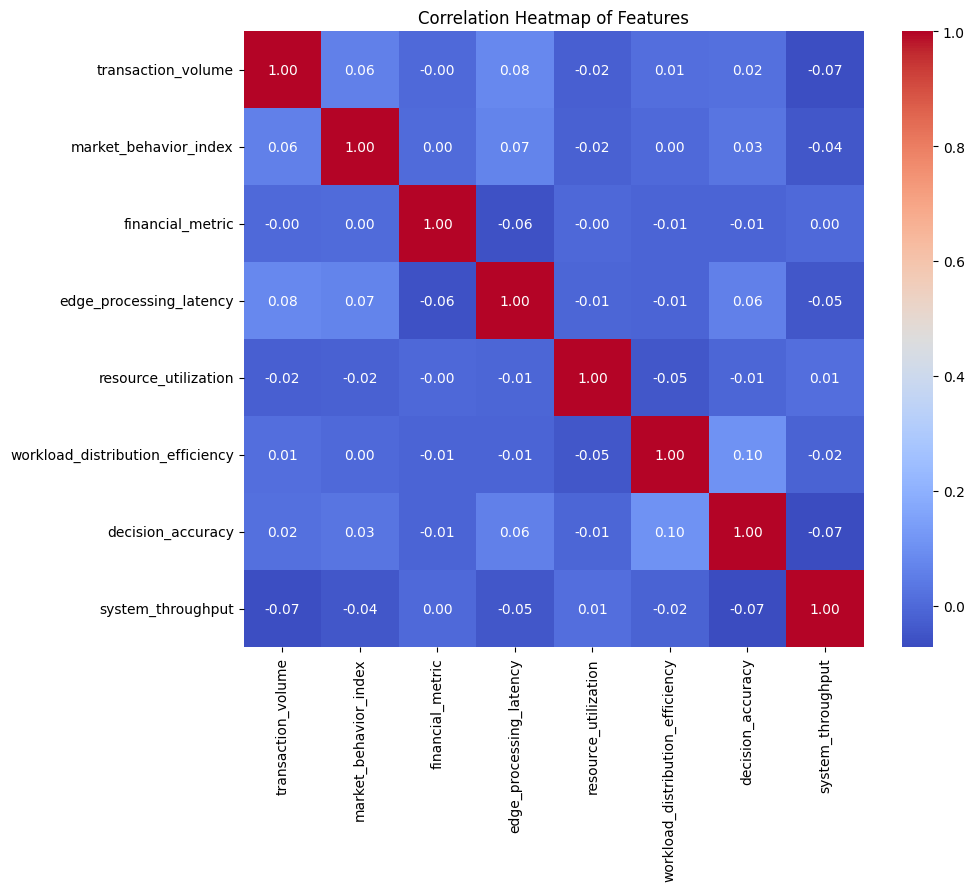

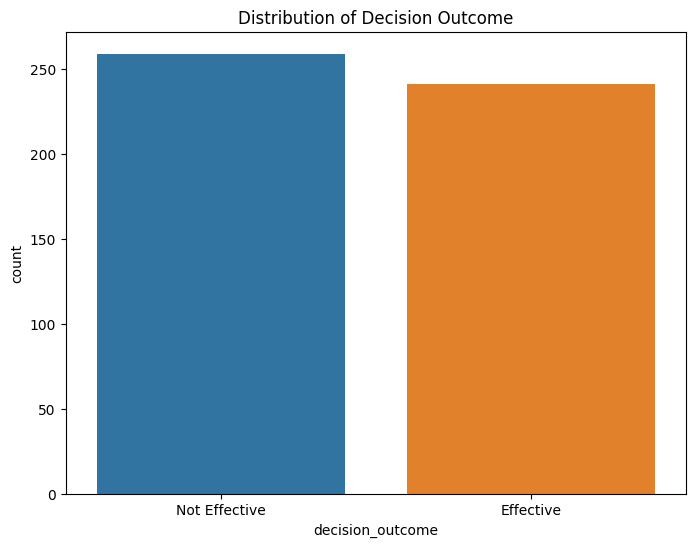

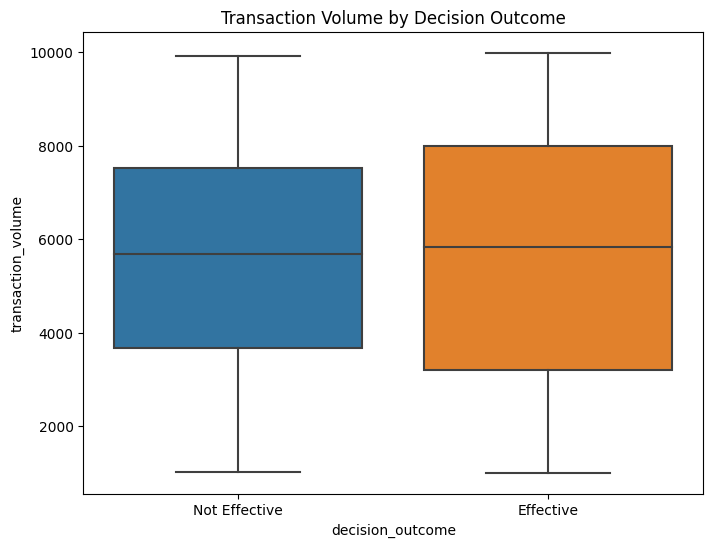

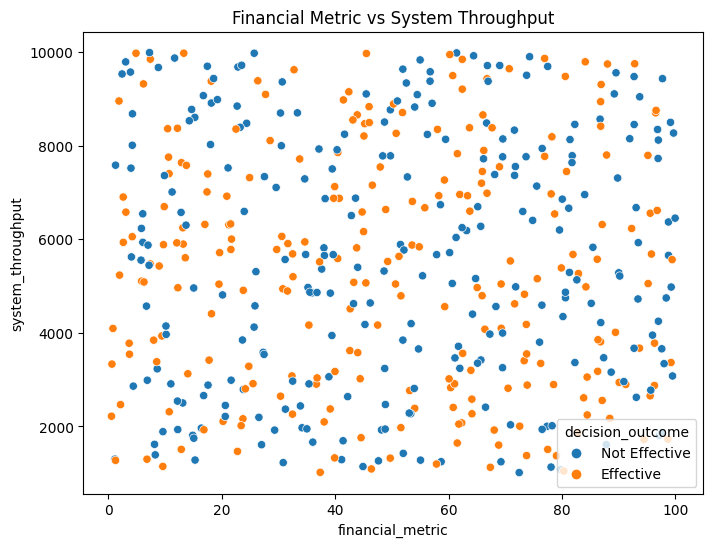

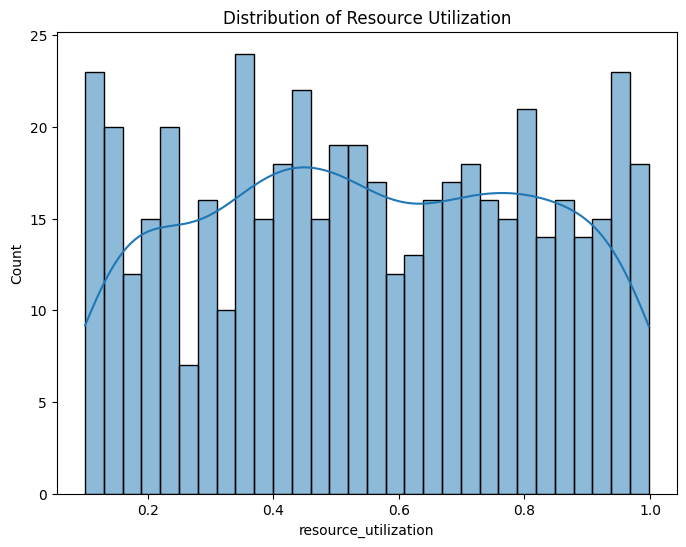

In [64]:
perform_eda(df)


In [65]:
X, y, _ = preprocess_data(df)


In [66]:
X_train, X_test, y_train, y_test = train_test_split_data(X, y)


In [67]:
models = {
        'Extra Trees': train_extra_trees(X_train, y_train),
        'CatBoost': train_catboost(X_train, y_train)    }
    

Loaded existing Extra Trees model
Loaded existing CatBoost model



Performance Metrics for Extra Trees:
Accuracy (A):  0.9700
Precision (P): 1.0000
Recall (R):    0.9412
F1 Score:      0.9697

Classification Report for Extra Trees:
               precision    recall  f1-score   support

Not Effective       0.94      1.00      0.97        49
    Effective       1.00      0.94      0.97        51

     accuracy                           0.97       100
    macro avg       0.97      0.97      0.97       100
 weighted avg       0.97      0.97      0.97       100



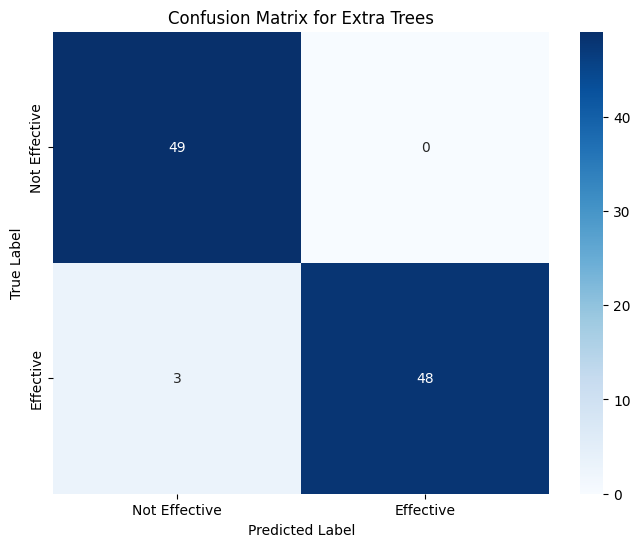


Performance Metrics for CatBoost:
Accuracy (A):  1.0000
Precision (P): 1.0000
Recall (R):    1.0000
F1 Score:      1.0000

Classification Report for CatBoost:
               precision    recall  f1-score   support

Not Effective       1.00      1.00      1.00        49
    Effective       1.00      1.00      1.00        51

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100



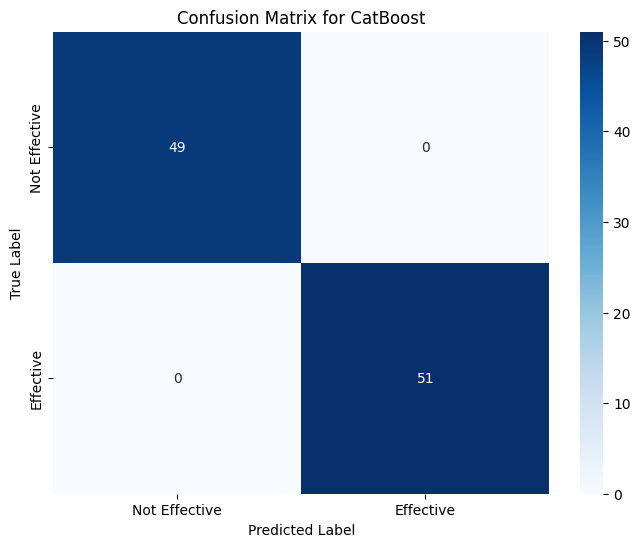

In [68]:
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = evaluate_performance(y_test, y_pred, name)
    

In [69]:
test_file_path = 'Test.csv'  # Replace with actual test file path
output_df = predict_test_data(test_file_path, model_name='CatBoost')

In [70]:
output_df

,transaction_volume,market_behavior_index,financial_metric,edge_processing_latency,resource_utilization,workload_distribution_efficiency,decision_accuracy,system_throughput,predicted_decision_outcome
0,1717,-0.702675,74.296381,472.107161,0.947553,78.856129,84.217637,9901,Not Effective
1,5946,-0.829301,34.658906,69.535674,0.710803,89.377454,78.128281,7289,Not Effective
2,6486,0.993749,37.166772,106.760540,0.425728,62.550069,76.067625,7928,Not Effective
3,9335,0.004390,98.766191,444.593201,0.634295,78.203701,79.414804,6368,Not Effective
4,5980,0.190770,4.106908,326.447298,0.109118,67.928923,77.245019,5621,Not Effective
5,8266,-0.865847,86.716446,150.094327,0.672486,82.831554,76.447379,8566,Not Effective
6,5491,0.499921,57.909673,409.814000,0.921958,62.019946,82.745525,5670,Not Effective
7,8192,-0.580189,43.917680,432.071298,0.651316,59.579647,97.235155,8658,Effective
8,6588,0.796109,72.553240,424.792026,0.886329,95.911954,85.211789,2003,Effective
9,2167,-0.926901,90.080116,379.970545,0.912208,61.042639,90.884684,2939,Effective


In [70]:
output_df

,transaction_volume,market_behavior_index,financial_metric,edge_processing_latency,resource_utilization,workload_distribution_efficiency,decision_accuracy,system_throughput,predicted_decision_outcome
0,1717,-0.702675,74.296381,472.107161,0.947553,78.856129,84.217637,9901,Not Effective
1,5946,-0.829301,34.658906,69.535674,0.710803,89.377454,78.128281,7289,Not Effective
2,6486,0.993749,37.166772,106.760540,0.425728,62.550069,76.067625,7928,Not Effective
3,9335,0.004390,98.766191,444.593201,0.634295,78.203701,79.414804,6368,Not Effective
4,5980,0.190770,4.106908,326.447298,0.109118,67.928923,77.245019,5621,Not Effective
5,8266,-0.865847,86.716446,150.094327,0.672486,82.831554,76.447379,8566,Not Effective
6,5491,0.499921,57.909673,409.814000,0.921958,62.019946,82.745525,5670,Not Effective
7,8192,-0.580189,43.917680,432.071298,0.651316,59.579647,97.235155,8658,Effective
8,6588,0.796109,72.553240,424.792026,0.886329,95.911954,85.211789,2003,Effective
9,2167,-0.926901,90.080116,379.970545,0.912208,61.042639,90.884684,2939,Effective
